PROGNOZOWANIE WYPOZYCZEN ROWEROW - REGRESJA

Wczytano 731 wierszy i 14 kolumn

--- KROK A: MODEL BAZOWY - TYLKO TEMPERATURA ---
Model bazowy wytrenowany

--- KROK B: MODEL KOŃCOWY - WSZYSTKIE CECHY + ELASTICNET ---
Rozpoczynam zoptymalizowane przeszukiwanie siatki (Grid Search)...
Fitting 5 folds for each of 80 candidates, totalling 400 fits


/home/bond/Documents/Machine-Learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.648364e+06, tolerance: 2.317e+04
  model = cd_fast.enet_coordinate_descent(
/home/bond/Documents/Machine-Learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.282644e+05, tolerance: 1.577e+04
  model = cd_fast.enet_coordinate_descent(
/home/bond/Documents/Machine-Learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check t


Najlepsze hiperparametry: {'preprocessor__num__polynomialfeatures__degree': 3, 'regressor__alpha': 0.1, 'regressor__l1_ratio': 0.9}

--- KROK C: PORÓWNANIE MODELI ---

=== PORÓWNANIE MODELU PIERWSZEGO Z KOŃCOWYM ===
                            Metryka Pierwszy Model (Tylko temp) Końcowy Model (Wszystkie cechy + ElasticNet)
        RMSE (im mniej, tym lepiej)                      630.13                                       443.41
         MAE (im mniej, tym lepiej)                      391.03                                       337.12
        MAPE (im mniej, tym lepiej)                      298.6%                                       221.4%
R^2 Train (im bliżej 1, tym lepiej)                       0.306                                        0.763


### PODSUMOWANIE WYNIKÓW

| Model | RMSE | MAE | MAPE | R^2 Train |
| --- | --- | --- | --- | --- |
| Pierwszy Model (Tylko temp) | 630.13 | 391.03 | 298.6% | 0.306 |
| Końcowy Model (ElasticNet, degree=3) | 443.41 | 337.12 | 221.4% | 0

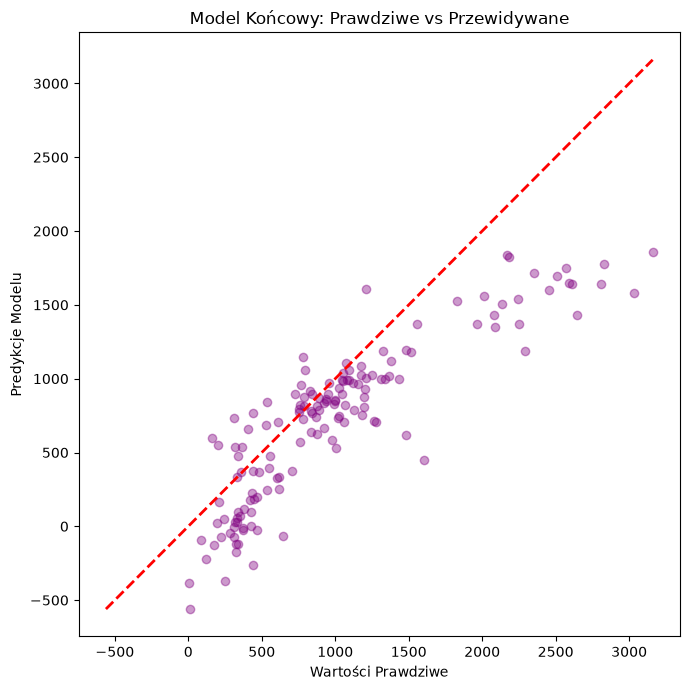

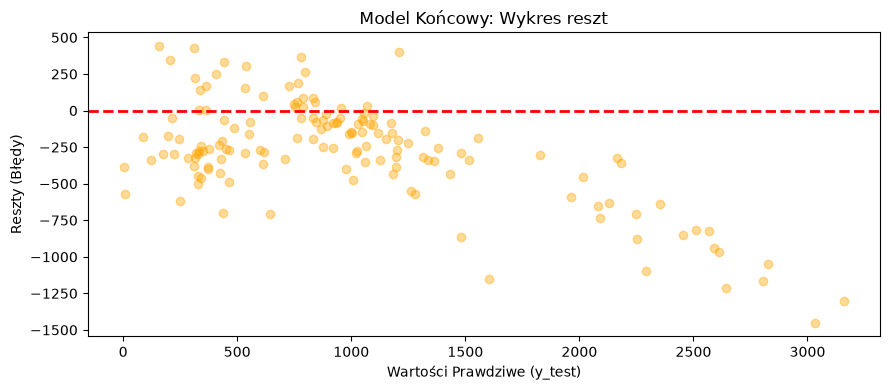

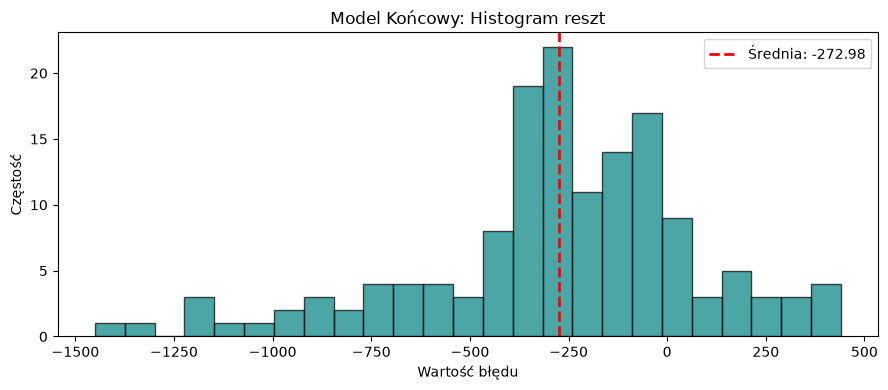


[SUKCES] Wykresy zostały wyświetlone i zapisane do plików PNG!


In [1]:
import os
from math import sqrt
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    PolynomialFeatures,
    PowerTransformer,
    StandardScaler,
)

# DLA JUPYTERA: żeby wykresy wyskakiwały w komórce
%matplotlib inline
plt.rcParams['font.family'] = 'DejaVu Sans' # żeby polskie znaki na wykresach działały

# =====================================================================
# 1. WCZYTANIE I PRZYGOTOWANIE DANYCH
# =====================================================================
print("="*80)
print("PROGNOZOWANIE WYPOZYCZEN ROWEROW - REGRESJA")
print("="*80)

bike_data_raw = pd.read_csv("daily-bike-share.csv")
bike_data = bike_data_raw.copy()

target = "rentals"
numeric_features = ["temp", "atemp", "hum", "windspeed"]
categorical_features = ["season", "mnth", "holiday", "weekday", "workingday", "weathersit"]

print(f"\nWczytano {bike_data.shape[0]} wierszy i {bike_data.shape[1]} kolumn")

# =====================================================================
# KROK A: PIERWSZY MODEL (Regresja liniowa jednej zmiennej 'temp')
# =====================================================================
print("\n--- KROK A: MODEL BAZOWY - TYLKO TEMPERATURA ---")
X_first = bike_data[["temp"]].copy()
y_first = bike_data[target].copy()

# Podział chronologiczny 80/20
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_first, y_first, test_size=0.2, shuffle=False
)

lr_model = LinearRegression()
lr_model.fit(X_train_f, y_train_f)

y_predict_train_f = lr_model.predict(X_train_f)
y_predict_test_f = lr_model.predict(X_test_f)
print("Model bazowy wytrenowany")

# =====================================================================
# KROK B: ZAAWANSOWANY MODEL KOŃCOWY (Wszystkie cechy + Pipeline + ElasticNet)
# =====================================================================
print("\n--- KROK B: MODEL KOŃCOWY - WSZYSTKIE CECHY + ELASTICNET ---")
X = bike_data[numeric_features + categorical_features].copy()
y = bike_data[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Walidacja krzyżowa 5-fold bez mieszania
cv = KFold(n_splits=5, shuffle=False)

# Potok dla cech numerycznych: normalizacja rozkładu -> standaryzacja -> wielomiany
numeric_transformer = Pipeline(
    steps=[
        ("logtransformer", PowerTransformer()), # Yeo-Johnson
        ("standardscaler", StandardScaler()),
        ("polynomialfeatures", PolynomialFeatures()), # degree ustawimy w GridSearch
    ]
)

# Potok dla cech kategorycznych: OneHot
categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Łączenie potoków
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# POPRAWKA: max_iter=10000 żeby GridSearch doszedł do zbieżności
final_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("regressor", ElasticNet(max_iter=10000))])

# Siatka hiperparametrów
params = {
    "preprocessor__num__polynomialfeatures__degree": [1, 2, 3, 4, 5],
    "regressor__alpha": [1e-3, 1e-2, 1e-1, 1.0], # siła regularyzacji
    "regressor__l1_ratio": [0.1, 0.5, 0.9, 1.0], # 1.0 = Lasso, 0.0 = Ridge
}

final_polynomial_regression_gridsearch = GridSearchCV(
    final_pipeline, params, scoring="neg_mean_squared_error", cv=cv, n_jobs=-1, verbose=1
)

print("Rozpoczynam zoptymalizowane przeszukiwanie siatki (Grid Search)...")
final_polynomial_regression_gridsearch.fit(X_train, y_train)

print("\nNajlepsze hiperparametry:", final_polynomial_regression_gridsearch.best_params_)

final_polynomial_regression_model = final_polynomial_regression_gridsearch.best_estimator_

# =====================================================================
# KROK C: OBLICZANIE METRYK I PORÓWNANIE
# =====================================================================
print("\n--- KROK C: PORÓWNANIE MODELI ---")
y_pred_final_train = final_polynomial_regression_model.predict(X_train)
y_pred_final_test = final_polynomial_regression_model.predict(X_test)

# Metryki modelu końcowego
final_rmse = sqrt(mean_squared_error(y_test, y_pred_final_test))
final_mae = mean_absolute_error(y_test, y_pred_final_test)
final_mape = mean_absolute_percentage_error(y_test, y_pred_final_test)
final_r2_train = r2_score(y_train, y_pred_final_train)

# Metryki modelu bazowego
first_rmse = sqrt(mean_squared_error(y_test_f, y_predict_test_f))
first_mae = mean_absolute_error(y_test_f, y_predict_test_f)
first_mape = mean_absolute_percentage_error(y_test_f, y_predict_test_f)
first_r2_train = r2_score(y_train_f, y_predict_train_f)

summary_data = {
    "Metryka": [
        "RMSE (im mniej, tym lepiej)",
        "MAE (im mniej, tym lepiej)",
        "MAPE (im mniej, tym lepiej)",
        "R^2 Train (im bliżej 1, tym lepiej)",
    ],
    "Pierwszy Model (Tylko temp)": [
        f"{first_rmse:.2f}",
        f"{first_mae:.2f}",
        f"{first_mape*100:.1f}%",
        f"{first_r2_train:.3f}",
    ],
    "Końcowy Model (Wszystkie cechy + ElasticNet)": [
        f"{final_rmse:.2f}",
        f"{final_mae:.2f}",
        f"{final_mape*100:.1f}%",
        f"{final_r2_train:.3f}",
    ],
}

comparison_df = pd.DataFrame(summary_data)
print("\n=== PORÓWNANIE MODELU PIERWSZEGO Z KOŃCOWYM ===")
print(comparison_df.to_string(index=False))

# PODSUMOWANIE W MARKDOWN ZGODNE Z OUTPUTEM
print("\n\n### PODSUMOWANIE WYNIKÓW\n")
print("| Model | RMSE | MAE | MAPE | R^2 Train |")
print("| --- | --- | --- | --- | --- |")
print(f"| Pierwszy Model (Tylko temp) | {first_rmse:.2f} | {first_mae:.2f} | {first_mape*100:.1f}% | {first_r2_train:.3f} |")
print(f"| Końcowy Model (ElasticNet, degree={final_polynomial_regression_gridsearch.best_params_['preprocessor__num__polynomialfeatures__degree']}) | {final_rmse:.2f} | {final_mae:.2f} | {final_mape*100:.1f}% | {final_r2_train:.3f} |")

poprawa_rmse = ((first_rmse - final_rmse) / first_rmse) * 100
print(f"\n**Wnioski:**")
print(f"1. Model końcowy zmniejszył błąd RMSE o **{poprawa_rmse:.1f}%** w porównaniu do modelu bazowego.")
print(f"2. Model końcowy wyjaśnia **{final_r2_train*100:.1f}%** zmienności danych treningowych.")
print(f"3. Najlepsze hiperparametry: {final_polynomial_regression_gridsearch.best_params_}")

# =====================================================================
# KROK D: GENEROWANIE I ZAPISYWANIE WYKRESÓW DIAGNOSTYCZNYCH
# =====================================================================
print("\n--- KROK D: WYKRESY ---")

# 1. Prawdziwe vs Przewidywane
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_final_test, alpha=0.4, color="purple")
ideal_line = np.linspace(
    min(y_test.min(), y_pred_final_test.min()),
    max(y_test.max(), y_pred_final_test.max()),
    100,
)
plt.plot(ideal_line, ideal_line, color="red", linestyle="--", linewidth=2)
plt.xlabel("Wartości Prawdziwe")
plt.ylabel("Predykcje Modelu")
plt.title("Model Końcowy: Prawdziwe vs Przewidywane")
plt.tight_layout()
plt.savefig("final_true_vs_pred.png", dpi=120) # Zapisz
plt.show() # POKAŻ W JUPYTERZE
plt.close() # Zamknij

# 2. Wykres reszt
final_errors = y_pred_final_test - y_test
plt.figure(figsize=(9, 4))
plt.scatter(y_test, final_errors, alpha=0.4, color="orange")
plt.axhline(0, color="red", linestyle="--", linewidth=2)
plt.xlabel("Wartości Prawdziwe (y_test)")
plt.ylabel("Reszty (Błędy)")
plt.title("Model Końcowy: Wykres reszt")
plt.tight_layout()
plt.savefig("final_residuals.png", dpi=120)
plt.show() # POKAŻ W JUPYTERZE
plt.close()

# 3. Histogram reszt
plt.figure(figsize=(9, 4))
plt.hist(final_errors, bins=25, color="teal", edgecolor="black", alpha=0.7)
plt.axvline(final_errors.mean(),color="red",linestyle="dashed",linewidth=2,label=f"Średnia: {final_errors.mean():.2f}",)
plt.title("Model Końcowy: Histogram reszt")
plt.xlabel("Wartość błędu")
plt.ylabel("Częstość")
plt.legend()
plt.tight_layout()
plt.savefig("final_residuals_hist.png", dpi=120)
plt.show() # POKAŻ W JUPYTERZE
plt.close()

print("\n[SUKCES] Wykresy zostały wyświetlone i zapisane do plików PNG!")
print("="*80)